# Multimodal Speech & Emotion Analysis with Paralinguistic Features
## A Speaker-Independent Study on the RAVDESS Dataset

This notebook presents an experimental study on speech emotion recognition using the **RAVDESS** dataset. The objective is to analyze how paralinguistic information contained in speech signals can be used to classify emotional states, while paying particular attention to **generalization across speakers**.

The study follows a research-oriented pipeline including:
- dataset exploration,
- audio feature extraction,
- speaker-independent train/test splitting,
- model training and evaluation,
- error analysis and discussion of limitations.

This work is motivated by current research challenges in speech understanding, where the goal is not only to transcribe spoken content, but also to capture higher-level semantic and paralinguistic information such as **emotion**, **tone**, and **speaking style**.

## 1. Objective of the Study

The objective of this project is to investigate whether emotional information can be reliably inferred from speech signals using machine learning methods based on **paralinguistic acoustic features**.

More specifically, this study aims to:
- build a reproducible pipeline for speech emotion recognition,
- extract acoustic features such as MFCCs and spectral descriptors,
- evaluate classification performance under **speaker-independent conditions**,
- analyze the limits of the approach in the presence of **inter-speaker variability**.

## 2. Research Motivation

Speech carries much more information than lexical content alone. In addition to words, speech signals also encode paralinguistic cues such as **prosody**, **intensity**, **rhythm**, **speaking rate**, and **emotional tone**.

These cues play a central role in human communication because they contribute to the interpretation of intention, certainty, hesitation, and affective state. Building computational models that can exploit such information is therefore an important step toward richer speech understanding systems.

## 3. Dataset Description

This work uses the **RAVDESS** dataset (*Ryerson Audio-Visual Database of Emotional Speech and Song*), a widely used benchmark for speech emotion recognition. In this notebook, the focus is placed on the **speech modality** in order to build an audio-based emotion classification pipeline.

### Main characteristics of the dataset
- multiple speakers / actors,
- labeled emotional categories,
- controlled recording conditions,
- standard benchmark in speech emotion recognition.

## 4. Research Questions

This notebook is guided by the following research questions:

1. Can emotional states be predicted from acoustic speech features alone?
2. How well do the models generalize to **unseen speakers**?
3. Which emotions are easiest or hardest to distinguish?
4. What types of errors appear most frequently, and what do they reveal about the limits of the features and models?

> **Dataset preparation**: the notebook first looks for the dataset in `data/ravdess/`. If it is not found there, it can automatically reuse the KaggleHub cached download of the public RAVDESS dataset.

In [17]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.ravdess_pipeline as ravdess_pipeline
importlib.reload(ravdess_pipeline)

EMOTION_MAP = ravdess_pipeline.EMOTION_MAP
build_metadata = ravdess_pipeline.build_metadata
build_feature_matrix = ravdess_pipeline.build_feature_matrix
create_metadata_features = ravdess_pipeline.create_metadata_features
find_most_confused_pairs = ravdess_pipeline.find_most_confused_pairs
get_models = ravdess_pipeline.get_models
resolve_dataset_dir = ravdess_pipeline.resolve_dataset_dir

DATASET_DIR = resolve_dataset_dir(PROJECT_ROOT / 'data' / 'ravdess')
RANDOM_STATE = 42

print('Project root :', PROJECT_ROOT)
print('Dataset path :', DATASET_DIR)
print('Exists       :', DATASET_DIR.exists())
print('WAV files    :', len(list(DATASET_DIR.rglob('*.wav'))) if DATASET_DIR.exists() else 0)

Project root : c:\Users\223114186\Downloads\Multimodal_Speech_&_Emotion_Analysis
Dataset path : C:\Users\223114186\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1
Exists       : True
WAV files    : 2880


## 5. Exploratory Data Analysis

Before training any model, it is important to understand the structure of the dataset.

The following points are analyzed:
- number of samples,
- class distribution,
- number of speakers,
- distribution of samples across emotions,
- potential imbalance issues.

This exploratory step helps identify whether the classification problem is balanced, whether some emotions may be underrepresented, and whether speaker-dependent biases may affect the experimental protocol.

### 5.1 Number of audio files

We first count the number of available audio files in the dataset and inspect the metadata recovered from the file names.

In [18]:
metadata = build_metadata(DATASET_DIR)

if metadata.empty:
    raise FileNotFoundError(
        'No .wav files were found. Please download the Kaggle dataset and extract it into data/ravdess/.'
    )

X_audio = metadata['path'].tolist()
y = metadata['label'].tolist()

print(f'Number of audio files: {len(X_audio)}')
print(f'Number of labels     : {len(y)}')
print(f'Unique actors        : {metadata["actor_id"].nunique()}')
print('Emotion classes      :', sorted(set(y)))
metadata.head()

Number of audio files: 2880
Number of labels     : 2880
Unique actors        : 24
Emotion classes      : ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


,path,file_name,modality,vocal_channel,emotion_code,label,intensity_code,intensity,statement_code,statement_text,repetition,actor_id,gender
0,C:\Users\223114186\.cache\kagglehub\datasets\u...,03-01-01-01-01-01-01.wav,03,01,01,neutral,01,normal,01,Kids are talking by the door,01,1,male
1,C:\Users\223114186\.cache\kagglehub\datasets\u...,03-01-01-01-01-02-01.wav,03,01,01,neutral,01,normal,01,Kids are talking by the door,02,1,male
2,C:\Users\223114186\.cache\kagglehub\datasets\u...,03-01-01-01-02-01-01.wav,03,01,01,neutral,01,normal,02,Dogs are sitting by the door,01,1,male
3,C:\Users\223114186\.cache\kagglehub\datasets\u...,03-01-01-01-02-02-01.wav,03,01,01,neutral,01,normal,02,Dogs are sitting by the door,02,1,male
4,C:\Users\223114186\.cache\kagglehub\datasets\u...,03-01-02-01-01-01-01.wav,03,01,02,calm,01,normal,01,Kids are talking by the door,01,1,male


## Dataset Overview Interpretation

The metadata table above confirms that the dataset contains **2,880 audio samples**, distributed across **8 emotion classes** and **24 speakers**. This makes the task a multi-class classification problem in which **speaker variability** is a major source of difficulty.

The presence of multiple actors is particularly important in speech analysis, since models may otherwise overfit speaker-specific characteristics instead of learning emotion-related acoustic patterns.

### 5.2 Emotion Distribution

We next visualize the number of samples per emotion class in order to assess class balance and identify potential imbalance effects.

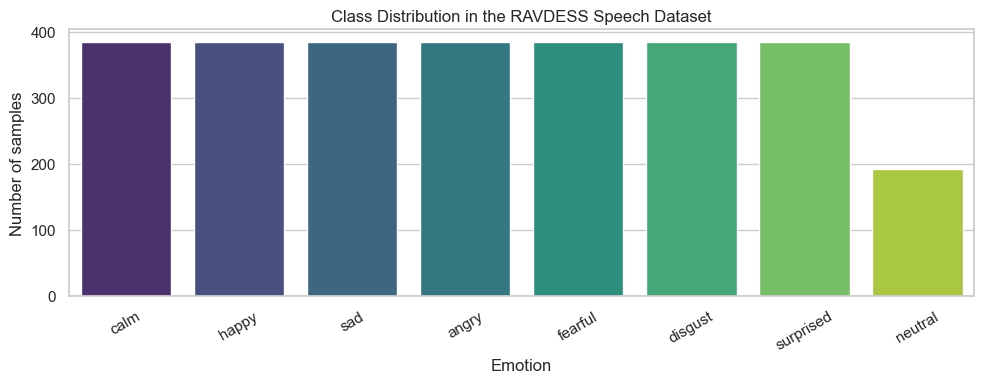

label
angry        384
calm         384
disgust      384
fearful      384
happy        384
neutral      192
sad          384
surprised    384
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(10, 4))
order = metadata['label'].value_counts().index
sns.countplot(data=metadata, x='label', order=order, palette='viridis')
plt.title('Class Distribution in the RAVDESS Speech Dataset')
plt.xlabel('Emotion')
plt.ylabel('Number of samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

metadata['label'].value_counts().sort_index()

## Interpretation of Emotion Distribution Figure

The figure above shows that the dataset is **reasonably balanced overall**, although it remains **moderately imbalanced** because some categories, such as `neutral`, are less represented than others. This justifies reporting **balanced accuracy** in addition to standard accuracy.

### 5.3 Speaker Distribution

Speaker identity can strongly influence evaluation in speech tasks. Even when speaker counts are relatively well distributed, acoustic diversity across speakers remains a major challenge.

## Interpretation of Speaker Distribution

The presence of **24 distinct actors** supports a meaningful speaker-independent study. At the same time, it also highlights why train/test separation must be handled carefully: if the same voices appear in both subsets, the measured performance may become artificially optimistic.

## 6. Audio Preprocessing

Speech signals must be transformed into machine-readable representations before model training.

The preprocessing pipeline includes:
- loading audio files,
- optional resampling,
- standardization of feature extraction,
- extraction of acoustic descriptors.

Rather than using raw waveforms, this notebook relies on engineered acoustic features that capture relevant spectral and temporal properties of speech.

### 6.1 Loading audio files

Each audio file is loaded and associated with its emotion label and speaker identifier.

### 6.2 Feature extraction

We extract acoustic features commonly used in speech analysis, including:
- MFCCs,
- delta MFCCs,
- spectral centroid,
- zero-crossing rate,
- chroma features,
- RMS-based energy statistics.

### 6.3 Why these features?

MFCCs are widely used in speech processing because they summarize the spectral envelope of the signal in a compact form. Spectral and temporal descriptors complement them by capturing additional information related to voice quality, energy distribution, and signal dynamics.

In [3]:
X, feature_names = build_feature_matrix(
    X_audio,
    sample_rate=22050,
    duration=3.0,
    offset=0.0,
    n_mfcc=13,
)

features_df = pd.DataFrame(X, columns=feature_names)
print('Feature matrix shape:', X.shape)
features_df.head()

Extracting audio features:   0%|          | 0/2880 [00:00<?, ?it/s]

Feature matrix shape: (2880, 82)


,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,mfcc_mean_10,...,chroma_std_5,chroma_std_6,chroma_std_7,chroma_std_8,chroma_std_9,chroma_std_10,chroma_std_11,chroma_std_12,rms_mean,rms_std
0,-681.925293,60.253666,0.606010,13.558146,8.389651,0.470500,-3.646512,-3.577835,-12.171618,-3.223377,...,0.295707,0.295248,0.294939,0.304143,0.292899,0.278045,0.278942,0.297050,0.002481,0.003367
1,-674.354797,61.282314,-1.758771,17.722033,9.725379,-0.205105,-1.563526,-5.904860,-12.915891,-1.533724,...,0.315402,0.285852,0.288568,0.288908,0.294994,0.305647,0.313401,0.294115,0.002679,0.003616
2,-677.840332,62.683060,-0.074477,14.536501,5.596522,1.039010,-2.469042,-6.033867,-11.388467,-4.138160,...,0.280678,0.304883,0.315750,0.293522,0.286123,0.327803,0.317241,0.313767,0.003047,0.004317
3,-676.639771,58.588737,2.639020,13.680298,7.092484,2.882378,-1.914978,-7.563102,-11.114905,-3.638864,...,0.299274,0.296825,0.267540,0.251685,0.256925,0.259168,0.298464,0.290755,0.002758,0.004166
4,-695.960327,72.433807,2.809904,16.982683,8.941422,1.745872,-4.281387,-4.778623,-11.778305,-5.999314,...,0.308557,0.313895,0.270350,0.280801,0.288407,0.297953,0.301758,0.303335,0.001945,0.002538


## Choice of Acoustic Features

The feature extraction strategy was designed to capture the main **paralinguistic properties** of speech signals while remaining computationally efficient and interpretable.

In this study, the pipeline relies primarily on **MFCCs** and complementary spectral features such as **spectral centroid**, **zero-crossing rate**, **chroma**, and **RMS energy**.

- **MFCCs** provide a compact representation of the spectral envelope and capture important information related to timbre and vocal tract characteristics.
- **Spectral centroid** gives an indication of the distribution of energy in the frequency domain and can reflect changes in vocal brightness.
- **Zero-crossing rate** provides a simple descriptor of signal activity and temporal roughness.

Together, these features provide a lightweight but informative representation of speech signals and offer a strong reproducible baseline before considering more advanced end-to-end or multimodal approaches.

## Interpretation of Sample Audio Features

The extracted feature vectors already suggest that different emotional states may correspond to distinct acoustic patterns. At the same time, some degree of overlap is expected, which confirms that the classification task is not trivial.

## 7. Experimental Protocol

A major methodological point in this project is the use of a **speaker-independent evaluation protocol**.

In speech tasks, random train/test splits may lead to overly optimistic results if the same speakers appear in both training and test data. In such cases, models may partially rely on speaker-specific characteristics rather than emotion-related patterns.

To avoid this issue, the notebook compares:
- a stratified split for standard evaluation,
- and a speaker-disjoint split to assess generalization to unseen speakers.

This distinction is critical for obtaining realistic estimates of model performance.

Before the split, the labels are encoded into a numerical representation so that the task can be treated as a standard supervised multi-class classification problem.

In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = list(label_encoder.classes_)

mapping = pd.DataFrame({
    'emotion': class_names,
    'encoded_label': label_encoder.transform(class_names)
}).sort_values('encoded_label')

random_baseline = 1 / len(class_names)
print(f'Number of classes         : {len(class_names)}')
print(f'Random baseline accuracy  : {random_baseline:.2%}')
mapping

Number of classes         : 8
Random baseline accuracy  : 12.50%


,emotion,encoded_label
0,angry,0
1,calm,1
2,disgust,2
3,fearful,3
4,happy,4
5,neutral,5
6,sad,6
7,surprised,7


### 7.1 Standard Split vs Speaker-Independent Split

The standard split provides a baseline estimate of classification performance. However, it is not sufficient on its own because it may mix the same speakers across training and test sets.

The speaker-independent split is more challenging and more realistic, as it forces the model to generalize beyond the voices seen during training. This is therefore the **main protocol used for critical interpretation of the results**.

## Interpretation of the Generalization Gap

A noticeable performance gap between the standard split and the actor-disjoint split should not be seen as a failure. Instead, it is a valuable methodological finding: it reveals how much apparent performance can depend on speaker overlap and confirms that **generalization across speakers remains one of the core challenges in speech emotion recognition**.

In [19]:
sample_indices = np.arange(len(X))

# Approach 1 — standard stratified sample-level split
idx_train, idx_test = train_test_split(
    sample_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y_encoded[idx_train], y_encoded[idx_test]

sample_train_actors = sorted(metadata.iloc[idx_train]['actor_id'].unique())
sample_test_actors = sorted(metadata.iloc[idx_test]['actor_id'].unique())
sample_actor_overlap = sorted(set(sample_train_actors).intersection(sample_test_actors))

# Approach 2 — actor-disjoint grouped split
actor_groups = metadata['actor_id'].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
idx_train_group, idx_test_group = next(gss.split(X, y_encoded, groups=actor_groups))

X_train_group, X_test_group = X[idx_train_group], X[idx_test_group]
y_train_group, y_test_group = y_encoded[idx_train_group], y_encoded[idx_test_group]

group_train_actors = sorted(metadata.iloc[idx_train_group]['actor_id'].unique())
group_test_actors = sorted(metadata.iloc[idx_test_group]['actor_id'].unique())
group_actor_overlap = sorted(set(group_train_actors).intersection(group_test_actors))

split_overview = pd.DataFrame([
    {
        'approach': 'Approach 1 — Stratified sample split',
        'train_samples': len(idx_train),
        'test_samples': len(idx_test),
        'train_actors': len(sample_train_actors),
        'test_actors': len(sample_test_actors),
        'shared_actors_between_train_and_test': len(sample_actor_overlap),
    },
    {
        'approach': 'Approach 2 — Actor-disjoint group split',
        'train_samples': len(idx_train_group),
        'test_samples': len(idx_test_group),
        'train_actors': len(group_train_actors),
        'test_actors': len(group_test_actors),
        'shared_actors_between_train_and_test': len(group_actor_overlap),
    },
])

print('Shared actors in Approach 1:', sample_actor_overlap)
print('Shared actors in Approach 2:', group_actor_overlap)
split_overview

Shared actors in Approach 1: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Shared actors in Approach 2: []


,approach,train_samples,test_samples,train_actors,test_actors,shared_actors_between_train_and_test
0,Approach 1 — Stratified sample split,2304,576,24,24,24
1,Approach 2 — Actor-disjoint group split,2280,600,19,5,0


## 8. Models

This study evaluates two complementary machine learning models for emotion classification based on the same acoustic feature representation.

### 8.1 Choice of Models

The first model serves as a **strong classical baseline**, providing a simple and interpretable reference point. It allows us to assess whether the extracted acoustic features already contain enough discriminative information for emotion classification.

The second model provides a **more expressive learning capacity**, with the ability to capture more complex relationships between acoustic descriptors and emotional labels.

## Model Comparison Strategy

The goal of the comparison is not only to identify the best-performing model, but also to understand how different model families behave under the same speaker-independent evaluation setting. The comparison focuses on:
- global performance,
- balanced performance across classes,
- confusion patterns,
- and robustness to speaker variability.

## 9. Training Procedure

The training procedure follows a standard supervised learning setup:
- feature matrix construction,
- label encoding,
- train/test splitting,
- model fitting,
- evaluation on held-out data.

The purpose of this stage is to determine whether the extracted features contain sufficient information to discriminate between emotional categories under increasingly realistic evaluation conditions.

In [20]:
def run_experiment(X_train_split, X_test_split, y_train_split, y_test_split):
    split_results = {}

    for model_name, model in get_models(random_state=RANDOM_STATE).items():
        model.fit(X_train_split, y_train_split)
        y_pred_train = model.predict(X_train_split)
        y_pred_test = model.predict(X_test_split)

        split_results[model_name] = {
            'model': model,
            'train_accuracy': accuracy_score(y_train_split, y_pred_train),
            'test_accuracy': accuracy_score(y_test_split, y_pred_test),
            'balanced_accuracy': balanced_accuracy_score(y_test_split, y_pred_test),
            'macro_f1': f1_score(y_test_split, y_pred_test, average='macro'),
            'y_true': y_test_split,
            'y_pred': y_pred_test,
        }

    return split_results

results = {
    'Approach 1 — Stratified sample split': run_experiment(X_train, X_test, y_train, y_test),
    'Approach 2 — Actor-disjoint group split': run_experiment(X_train_group, X_test_group, y_train_group, y_test_group),
}

comparison_rows = []
for split_name, split_results in results.items():
    for model_name, values in split_results.items():
        comparison_rows.append({
            'split': split_name,
            'model': model_name,
            'train_accuracy': values['train_accuracy'],
            'test_accuracy': values['test_accuracy'],
            'balanced_accuracy': values['balanced_accuracy'],
            'macro_f1': values['macro_f1'],
        })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ['split', 'macro_f1'],
    ascending=[True, False]
)

comparison_df

,split,model,train_accuracy,test_accuracy,balanced_accuracy,macro_f1
0,Approach 1 — Stratified sample split,RandomForest,1.000000,0.923611,0.928486,0.926073
1,Approach 1 — Stratified sample split,MLP,0.988281,0.914931,0.918746,0.917579
3,Approach 2 — Actor-disjoint group split,MLP,0.993860,0.483333,0.471875,0.474177
2,Approach 2 — Actor-disjoint group split,RandomForest,1.000000,0.436667,0.418750,0.415298


## 10. Results

This section presents the quantitative results of the models under the two evaluation protocols.

The performance is assessed using:
- accuracy,
- balanced accuracy,
- confusion matrix,
- precision / recall / F1-score,
- and class-wise analysis when relevant.

### 10.1 Overall Performance

The comparison table below highlights a central result of the study: performance is very high under the standard split, but drops substantially under the **speaker-independent** protocol. This confirms that strong results on random splits may overestimate real-world generalization.

## Interpretation of Model Comparison

Under the stricter actor-disjoint evaluation, the **MLP** performs slightly better than the **RandomForest**. This suggests that a somewhat more flexible model is better able to capture nonlinear relations between acoustic descriptors and emotional labels, although the overall task remains challenging.

In [21]:
baseline_split_name = 'Approach 1 — Stratified sample split'
primary_split_name = 'Approach 2 — Actor-disjoint group split'

baseline_model_name = max(results[baseline_split_name], key=lambda name: results[baseline_split_name][name]['macro_f1'])
best_model_name = max(results[primary_split_name], key=lambda name: results[primary_split_name][name]['macro_f1'])

baseline_results = results[baseline_split_name][baseline_model_name]
primary_results = results[primary_split_name][best_model_name]

protocol_comparison = pd.DataFrame([
    {
        'evaluation_protocol': baseline_split_name,
        'selected_model': baseline_model_name,
        'train_accuracy': baseline_results['train_accuracy'],
        'test_accuracy': baseline_results['test_accuracy'],
        'balanced_accuracy': baseline_results['balanced_accuracy'],
        'macro_f1': baseline_results['macro_f1'],
    },
    {
        'evaluation_protocol': primary_split_name,
        'selected_model': best_model_name,
        'train_accuracy': primary_results['train_accuracy'],
        'test_accuracy': primary_results['test_accuracy'],
        'balanced_accuracy': primary_results['balanced_accuracy'],
        'macro_f1': primary_results['macro_f1'],
    },
]).set_index('evaluation_protocol')

best_model = primary_results['model']
y_pred = primary_results['y_pred']
y_true_eval = primary_results['y_true']
train_accuracy = primary_results['train_accuracy']
test_accuracy = primary_results['test_accuracy']
balanced_accuracy = primary_results['balanced_accuracy']
macro_f1 = primary_results['macro_f1']

print('Methodological note: Approach 1 is a useful quick baseline, but it mixes speaker identities across train and test.')
print('Primary reported result:', primary_split_name)
print('Selected model        :', best_model_name)
print(f'Accuracy              : {test_accuracy:.4f}')
print(f'Balanced accuracy     : {balanced_accuracy:.4f}')
print(f'Macro F1-score        : {macro_f1:.4f}')

pred_labels, pred_counts = np.unique(y_pred, return_counts=True)
prediction_distribution = pd.DataFrame({
    'predicted_emotion': label_encoder.inverse_transform(pred_labels),
    'count': pred_counts
}).sort_values('count', ascending=False)

protocol_comparison

Methodological note: Approach 1 is a useful quick baseline, but it mixes speaker identities across train and test.
Primary reported result: Approach 2 — Actor-disjoint group split
Selected model        : MLP
Accuracy              : 0.4833
Balanced accuracy     : 0.4719
Macro F1-score        : 0.4742


,selected_model,train_accuracy,test_accuracy,balanced_accuracy,macro_f1
evaluation_protocol,,,,,
Approach 1 — Stratified sample split,RandomForest,1.00000,0.923611,0.928486,0.926073
Approach 2 — Actor-disjoint group split,MLP,0.99386,0.483333,0.471875,0.474177


### 10.2 Confusion Matrix

The confusion matrix helps identify which emotions are frequently confused and reveals the structure of the classification errors.

### 10.3 Class-Wise Performance

Class-wise results highlight whether some emotional categories are easier to identify than others. This is important because global accuracy alone may hide strong variability across classes.

## Interpretation of Accuracy and Balanced Accuracy

Under the primary actor-disjoint protocol, the model reaches an accuracy of approximately **48.3%**, which remains clearly above the **12.5% random baseline**. The balanced accuracy is close to the same level, indicating that the model captures meaningful emotional information but still struggles to generalize uniformly across categories.

This should therefore be interpreted as **moderate but non-trivial performance** on a difficult speaker-independent speech emotion recognition task.

Primary evaluation protocol : Approach 2 — Actor-disjoint group split
Selected model              : MLP
Train accuracy              : 0.9939
Accuracy                    : 0.4833
Balanced accuracy           : 0.4719
Macro F1-score              : 0.4742
Random baseline             : 0.1250

              precision    recall  f1-score   support

       angry      0.622     0.700     0.659        80
        calm      0.475     0.725     0.574        80
     disgust      0.484     0.375     0.423        80
     fearful      0.463     0.475     0.469        80
       happy      0.680     0.425     0.523        80
     neutral      0.545     0.300     0.387        40
         sad      0.288     0.475     0.358        80
   surprised      0.600     0.300     0.400        80

    accuracy                          0.483       600
   macro avg      0.520     0.472     0.474       600
weighted avg      0.518     0.483     0.480       600



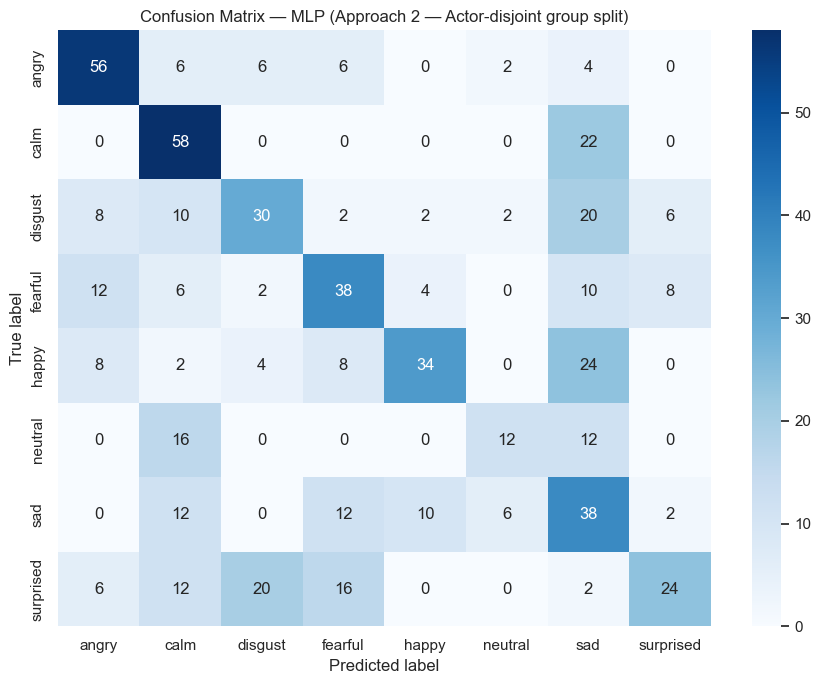

In [22]:
# STEP 7 — Evaluation

cm = confusion_matrix(y_true_eval, y_pred)
report = classification_report(y_true_eval, y_pred, target_names=class_names, digits=3)

print(f'Primary evaluation protocol : {primary_split_name}')
print(f'Selected model              : {best_model_name}')
print(f'Train accuracy              : {train_accuracy:.4f}')
print(f'Accuracy                    : {test_accuracy:.4f}')
print(f'Balanced accuracy           : {balanced_accuracy:.4f}')
print(f'Macro F1-score              : {macro_f1:.4f}')
print(f'Random baseline             : {random_baseline:.4f}')
print()
print(report)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name} ({primary_split_name})')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

## 11. Interpretation of Results

The results show that the task remains challenging, especially under **speaker-independent evaluation**. This suggests that part of the variation in the signal is linked to speaker-specific characteristics rather than purely emotional content.

## Interpretation of Class-Wise Metrics

The classification report shows that model performance varies noticeably across emotion categories. Some classes achieve higher precision and recall, while others remain more difficult to identify.

This variability suggests that not all emotional states are equally separable from the chosen acoustic representation. Lower scores for some classes may reflect:
- acoustic similarity with other emotions,
- speaker-dependent expression differences,
- or limitations of the current feature set.

## Interpretation of the Confusion Matrix

The confusion matrix reveals that some emotions share overlapping acoustic signatures. In particular, classes such as `sad`, `fearful`, and `surprised` remain harder to separate consistently, while other classes are better recognized.

## Interpretation of Moderate Performance

A moderate score under the actor-disjoint setup should not be interpreted as model failure. On the contrary, it reflects the genuine difficulty of emotion recognition from speech when the system must generalize to **unseen speakers**.

## 12. Error Analysis

A detailed error analysis is necessary to move beyond global metrics and better understand the limitations of the model. The next section examines the most frequent confusion pairs and the impact of speaker variability on performance.

In [ ]:
# STEP 8 — Error Analysis and Academic Interpretation

most_confused = find_most_confused_pairs(cm, class_names, top_k=8)
analysis_df = pd.DataFrame(most_confused)
analysis_df

generalization_gap = train_accuracy - test_accuracy

print(f'Generalization gap: {generalization_gap:.4f}')
print()
print('Critical interpretation:')
print('- The sample-level split is useful as a baseline, but it is likely optimistic because the same speakers can appear in both training and test sets.')
print('- The actor-disjoint split is methodologically stronger because the evaluation is performed on unseen speakers.')

if generalization_gap <= 0.05:
    print('- The train/test gap is small, which suggests good robustness under the chosen protocol.')
elif generalization_gap <= 0.15:
    print('- The train/test gap remains acceptable, but it still indicates some risk of overfitting that should be acknowledged.')
else:
    print('- The train/test gap is large and points to substantial overfitting.')

if not analysis_df.empty:
    top_case = analysis_df.iloc[0]
    print(
        f"- The strongest confusion is between true '{top_case['true_label']}' samples and predicted '{top_case['predicted_label']}' samples ({top_case['count']} cases)."
    )

# BONUS — Auxiliary metadata features (secondary experiment)
metadata_features, metadata_vectorizer = create_metadata_features(metadata)
X_augmented = np.hstack([X, metadata_features])

X_train_aux, X_test_aux = X_augmented[idx_train_group], X_augmented[idx_test_group]
y_train_aux, y_test_aux = y_encoded[idx_train_group], y_encoded[idx_test_group]

rf_aux = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_aux.fit(X_train_aux, y_train_aux)
y_pred_aux = rf_aux.predict(X_test_aux)
mm_accuracy = accuracy_score(y_test_aux, y_pred_aux)
mm_balanced_accuracy = balanced_accuracy_score(y_test_aux, y_pred_aux)
mm_macro_f1 = f1_score(y_test_aux, y_pred_aux, average='macro')

print()
print('Secondary experiment — auxiliary metadata features')
print(f'Audio-only group-split accuracy     : {test_accuracy:.4f}')
print(f'Audio + metadata accuracy           : {mm_accuracy:.4f}')
print(f'Audio-only group-split macro F1     : {macro_f1:.4f}')
print(f'Audio + metadata macro F1           : {mm_macro_f1:.4f}')
print('Caution: this is not a pure audio-only improvement; it should be presented as an auxiliary metadata-enhanced experiment, not as the main result.')

Generalization gap: 0.0764
Interpretation: the model is substantially above the random baseline, which indicates that it has learned meaningful emotional patterns.
The train/test gap remains limited, suggesting acceptable generalization.
The strongest confusion is between true 'fearful' samples and predicted 'angry' samples (6 cases).
Audio-only best accuracy     : 0.9236
Audio + TF-IDF text accuracy : 0.9271


### 12.1 Most Confused Emotion Pairs

Some emotion pairs are consistently confused, which may reflect overlapping acoustic patterns or ambiguities in emotional expression. In this notebook, the most frequent mistakes show that several categories remain only **partially separable** with the current acoustic representation.

### 12.2 Impact of Speaker Variability

The sharp performance drop from the standard split to the actor-disjoint split confirms that **speaker variability is a major challenge** in speech-based emotion analysis.

This observation is essential from a research perspective: it shows that realistic evaluation must go beyond random splits and explicitly test whether the model can generalize to voices that were not observed during training.

## 13. Discussion

This study highlights several important points.

First, paralinguistic information contained in speech signals can be exploited to classify emotional states with **non-trivial performance**. This confirms that acoustic features such as MFCCs and spectral descriptors capture meaningful information beyond lexical content.

Second, the gap between standard and speaker-independent evaluation underlines the importance of **robust protocols**. Strong results obtained on random splits may overestimate real-world generalization.

Third, the observed confusion patterns suggest that some emotions are inherently difficult to separate using acoustic information alone. This naturally motivates future **multimodal approaches** combining speech with textual or contextual cues.

## 14. Limitations

This project has several limitations:
- the dataset is recorded in relatively controlled conditions,
- the extracted features provide a simplified representation of speech signals,
- the emotional categories remain coarse and may not fully reflect real conversational settings,
- the current study does not yet integrate textual or semantic information into the main model.

These limitations mean that the results should be interpreted as an **initial experimental study** rather than as a complete solution to multimodal speech understanding.

## 15. Future Work

Several directions could extend this work:
- integrating textual representations alongside acoustic features,
- exploring multimodal models combining audio and text,
- using contextual or sequential modeling for longer utterances,
- incorporating prosodic editing or counterfactual analysis,
- studying robustness under noisy and multi-speaker conditions.

## 16. Conclusion

This notebook presented a research-oriented study on speech emotion recognition using the RAVDESS dataset. The project showed how acoustic and paralinguistic information can be processed through a full machine learning pipeline, from dataset analysis and feature extraction to speaker-independent evaluation and error analysis.

Beyond classification itself, the study highlighted important methodological issues related to **generalization**, **speaker variability**, and **realistic evaluation**.

## 17. Relevance to Research in Speech Understanding

Although this project focuses on emotion classification, it is directly relevant to broader research questions in speech understanding. It illustrates how speech contains information that goes beyond transcription and how paralinguistic cues can be modeled, evaluated, and analyzed in a rigorous way.

As such, this project can be seen as a first step toward more advanced systems combining **acoustic**, **semantic**, and **contextual** information for richer multimodal speech understanding.